## Import libraries

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import Image


project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)



In [3]:

from fmu2ml.analysis.multivariate_effect_analysis.analyzers import (
    PartialCorrelationAnalyzer,
    MultipleRegressionAnalyzer,
    LaggedEffectAnalyzer,
    AutocorrelationAnalyzer
)
from fmu2ml.analysis.multivariate_effect_analysis.visualizers import *
from fmu2ml.analysis.input_output_relations.analyzers import DataGenerator
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

In [4]:
SYSTEM_NAME = 'lassen'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()
num_cdus = config['NUM_CDUS']

In [5]:
# Configuration
TOTAL_TIMESTEPS = 7200
SAMPLES_PER_HOUR = 60
MAX_LAG = 30
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/multivariate_effect'
DATA_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '128GB'
KEY_OUTPUTS = ['T_sec_r_C', 'W_flow_CDUP_kW', 'V_flow_sec_GPM','p_sec_r_psig']

print(f"System: {SYSTEM_NAME}")
print(f"Total timesteps: {TOTAL_TIMESTEPS}")
print(f"Workers: {N_WORKERS}")
print(f"Max lag: {MAX_LAG}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Number of CDUs: {num_cdus}")
print(f"Configuration loaded for {SYSTEM_NAME}")



System: lassen
Total timesteps: 7200
Workers: 48
Max lag: 30
Output dir: ../results/lassen/data_analysis/multivariate_effect
Number of CDUs: 44
Configuration loaded for lassen


In [6]:
INPUT_RANGES

{'Q_flow': (10.86, 34.43),
 'T_Air': (288.15, 308.15),
 'T_ext': (283.15, 313.15)}

In [7]:
data_file = os.path.join(DATA_DIR, 'sensitivity_data.parquet')


In [8]:
# Generate or Load Data
data_generator = DataGenerator(
    n_workers=N_WORKERS,
    **config
)
data = None
if os.path.exists(data_file):
    print("Importing the previously generated data")
    data = pd.read_parquet(data_file)
else:
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    # Save data
    data.to_parquet(data_file)
    print(f"Data saved to: {data_file}")
    
print(f"Data shape: {data.shape}")
print(f"\nColumns: {list(data.columns[:10])}...")




2026-02-05 19:45:50 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: lassen
2026-02-05 19:45:50 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 44


Importing the previously generated data
Data shape: (7200, 1105)

Columns: ['simulator[1].datacenter[1].summary.m_flow_prim', 'simulator[1].datacenter[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s', 'simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C']...


## 1. Partial Correlation Analysis

In [9]:

# Partial Correlation Analysis - Setup
partial_analyzer = PartialCorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    significance_threshold=0.05,
    edge_threshold=0.1,
    method='pearson'
)

prepared_data = partial_analyzer.prepare_data(data)


2026-01-29 18:32:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - PartialCorrelationAnalyzer initialized for system: lassen
2026-01-29 18:32:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Method: pearson, Significance threshold: 0.05
2026-01-29 18:32:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Preparing data for partial correlation analysis...
2026-01-29 18:32:37 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


In [45]:

# Partial Correlation Analysis - Compute
print("Computing partial correlations...")
partial_df = partial_analyzer.analyze_partial_correlations(prepared_data)

print(f"\nTotal relationships analyzed: {len(partial_df)}")
print(f"Direct effects identified: {partial_df['is_direct_effect'].sum()}")


2026-01-29 18:41:44 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-29 18:41:44 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Initializing Dask cluster for partial correlation analysis...
2026-01-29 18:41:45 - distributed.scheduler - INFO - State start


Computing partial correlations...


2026-01-29 18:41:45 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:39043
2026-01-29 18:41:45 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:45033/status
2026-01-29 18:41:45 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:36445'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45081'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45515'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38939'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34545'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37115'
2026-01-29 18:41:48 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:32869'
2026-01-29 18:41:48 - distributed.nanny


Total relationships analyzed: 36
Direct effects identified: 29


2026-01-29 18:43:47 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:43:47 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:43:47 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:43:47 - distributed.core - INFO - Event loop was unresponsive in Nanny for 4.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 18:43:47 - distributed.core - INFO - Event loop was unresponsive in Nanny

In [46]:

# Display top direct effects
direct_effects = partial_df[partial_df['is_direct_effect']].copy()
direct_effects['abs_partial'] = direct_effects['partial_corr'].abs()
top_direct = direct_effects.nlargest(10, 'abs_partial')

print("\nTop 10 Direct Effects:")
print(top_direct[['input', 'output', 'pearson_corr', 'partial_corr', ]])



Top 10 Direct Effects:
     input           output  pearson_corr  partial_corr
27   T_ext       T_prim_s_C      0.983826      0.983467
11  Q_flow              pue     -0.963898     -0.952052
28   T_ext       T_prim_r_C      0.913797      0.906431
29   T_ext        T_sec_s_C      0.887958      0.905503
30   T_ext        T_sec_r_C      0.885877      0.905488
26   T_ext   W_flow_CDUP_kW      0.886538      0.903806
33   T_ext     p_sec_s_psig      0.878721      0.901122
34   T_ext     p_sec_r_psig      0.878721      0.901121
32   T_ext    p_prim_r_psig      0.844640      0.839745
24   T_ext  V_flow_prim_GPM      0.814309      0.809558


In [47]:
# Partial Correlation - Visualizations
comparison_data = partial_analyzer.compute_correlation_comparison(prepared_data)
network_data = partial_analyzer.build_network_data(comparison_data['full_results'])

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'partial_correlation')
os.makedirs(viz_dir, exist_ok=True)

create_correlation_comparison_chart(partial_df, viz_dir)
create_correlation_heatmaps(comparison_data, viz_dir)
create_network_diagram(network_data, viz_dir, layout='spring')
create_confounding_analysis_plot(partial_df, viz_dir)




2026-01-29 18:43:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing correlation comparison matrices...
2026-01-29 18:43:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computing partial correlations...
2026-01-29 18:43:03 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Executing 36 partial correlation analyses...
2026-01-29 18:43:41 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Computed 36 partial correlations
2026-01-29 18:43:41 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Building network diagram data...
2026-01-29 18:43:41 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.partial_correlation_analyzer - INFO - Network: 15 nodes, 29 significant edges
2026-01-29 18:43:41 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.p

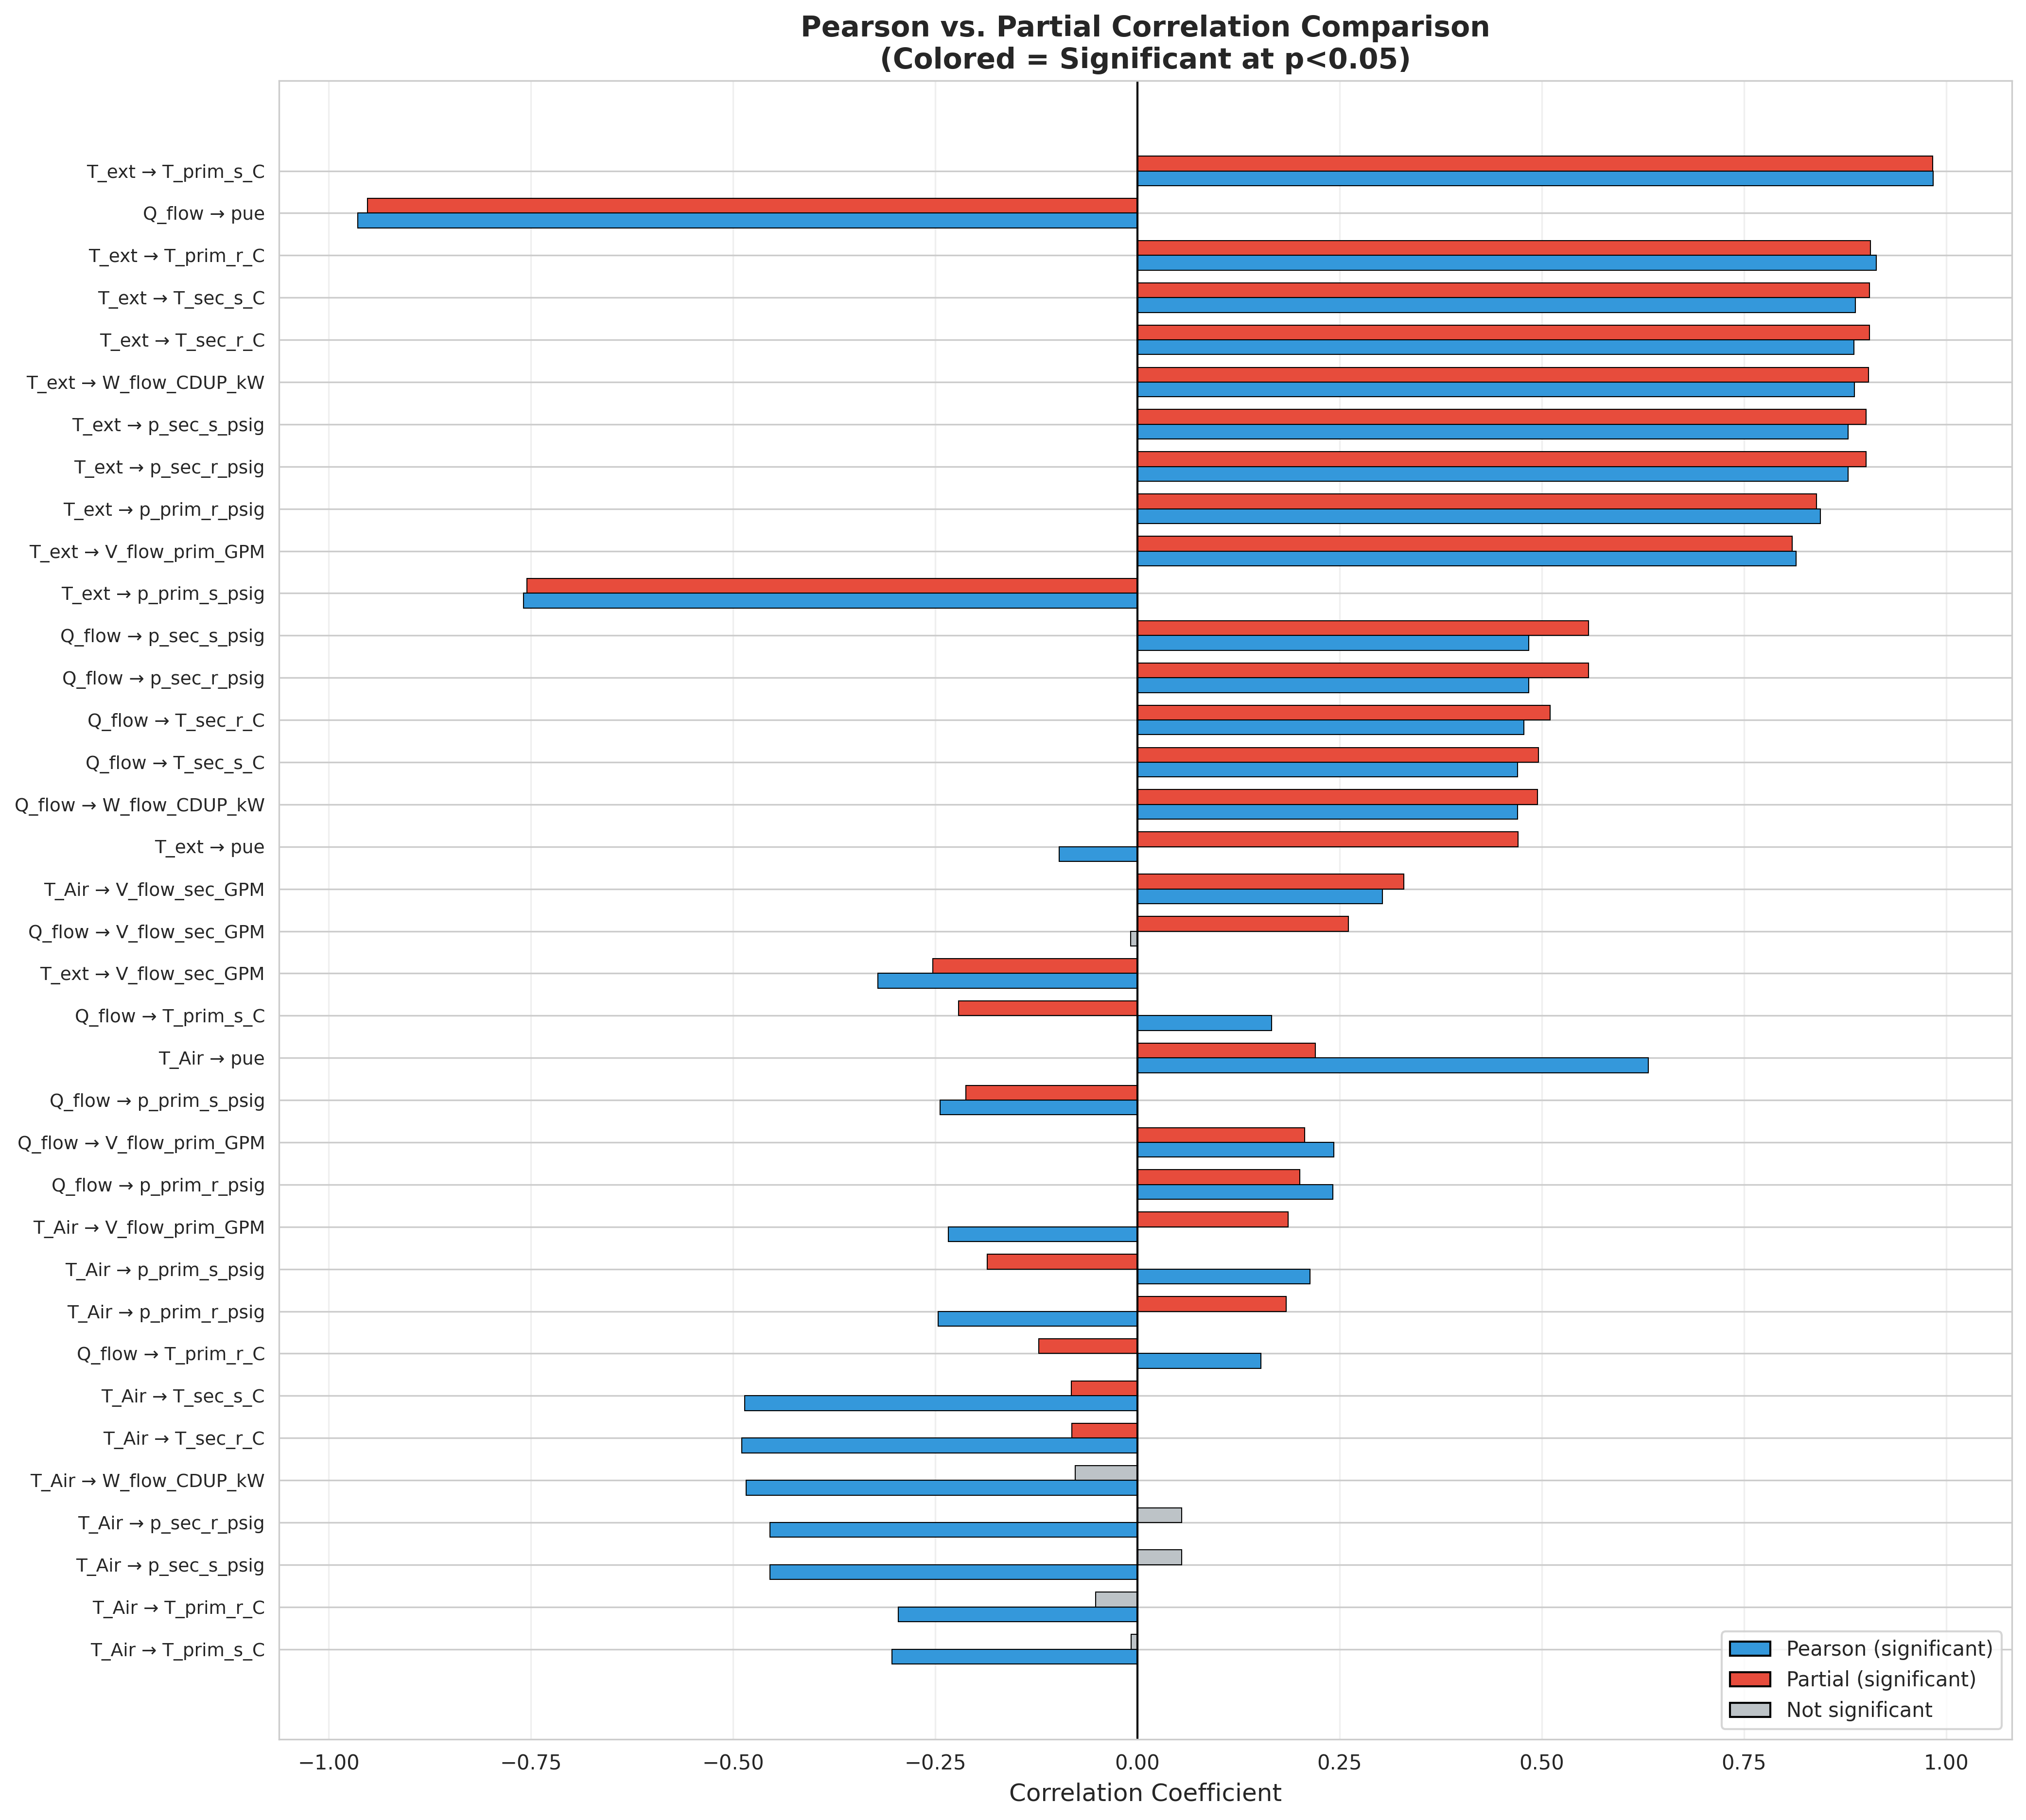

In [48]:
Image(filename=os.path.join(viz_dir, 'correlation_comparison.png'))


## 2. Multiple Regression Analysis

In [53]:
# Multiple Regression Analysis - Setup
regression_analyzer = MultipleRegressionAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    vif_threshold=10.0,
    significance_threshold=0.05,
    standardize=True,
    bootstrap_samples=1000
)

reg_prepared_data = regression_analyzer.prepare_data(data)
print("Data prepared for regression analysis")


2026-01-29 18:45:46 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - MultipleRegressionAnalyzer initialized for system: lassen
2026-01-29 18:45:46 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - VIF threshold: 10.0, Standardize: True
2026-01-29 18:45:46 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Preparing data for multiple regression analysis...
2026-01-29 18:45:46 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Prepared data: 3 inputs, 11 outputs, 1 datacenter outputs


Data prepared for regression analysis


In [54]:

# Multiple Regression Analysis - Compute
print("Performing multiple regression analysis...")
regression_df = regression_analyzer.analyze_multiple_regression(reg_prepared_data)

print(f"\nOutputs analyzed: {len(regression_df)}")
print(f"Mean R²: {regression_df['r2'].mean():.3f}")
print(f"Well-explained outputs (R² > 0.7): {(regression_df['r2'] > 0.7).sum()}")

# Display best models
top_models = regression_df.nlargest(5, 'r2')
print("\nTop 5 Best Explained Outputs:")
print(top_models[['output', 'r2', 'adj_r2', 'f_statistic', 'f_pvalue']])


2026-01-29 18:45:52 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Performing multiple regression analysis...
2026-01-29 18:45:52 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Initializing Dask cluster for multiple regression analysis...
2026-01-29 18:45:52 - distributed.scheduler - INFO - State start
2026-01-29 18:45:52 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:44419
2026-01-29 18:45:52 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:32885/status
2026-01-29 18:45:52 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Performing multiple regression analysis...


2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37785'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38089'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42057'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40147'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35781'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40931'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45031'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39025'
2026-01-29 18:45:52 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43317'
2026-01-29 18:45:53 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34517'
2026-01-29 18:45:53 - distribu


Outputs analyzed: 12
Mean R²: 0.775
Well-explained outputs (R² > 0.7): 9

Top 5 Best Explained Outputs:
            output        r2    adj_r2  f_statistic      f_pvalue
3       T_prim_s_C  0.970277  0.970127  6485.191183  1.110223e-16
11             pue  0.945152  0.944876  3423.482859  1.110223e-16
6        T_sec_r_C  0.871343  0.870696  1345.495396  1.110223e-16
5        T_sec_s_C  0.870140  0.869486  1331.181753  1.110223e-16
2   W_flow_CDUP_kW  0.867791  0.867126  1304.005620  1.110223e-16


2026-01-29 18:48:11 - distributed.scheduler - INFO - Remove client Client-a6b0859b-fd6c-11f0-99c1-0a580a221eb4
2026-01-29 18:48:11 - distributed.core - INFO - Received 'close-stream' from tcp://127.0.0.1:35468; closing.
2026-01-29 18:48:11 - distributed.scheduler - INFO - Remove client Client-a6b0859b-fd6c-11f0-99c1-0a580a221eb4
2026-01-29 18:48:11 - distributed.scheduler - INFO - Close client connection: Client-a6b0859b-fd6c-11f0-99c1-0a580a221eb4
2026-01-29 19:55:57 - distributed.core - INFO - Event loop was unresponsive in Scheduler for 3.80s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 19:55:57 - distributed.core - INFO - Event loop was unresponsive in Nanny for 3.80s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
2026-01-29 19:55:57 - distributed.core - INFO - Event loop was unresponsive in Nanny 

In [55]:

# Multiple Regression - Detailed Results
# Extract beta coefficients for a specific output
example_output = KEY_OUTPUTS[0]
output_data = regression_df[regression_df['output'] == example_output].iloc[0]

print(f"\nRegression Model for {example_output}:")
print(f"R² = {output_data['r2']:.4f}")
print(f"Adjusted R² = {output_data['adj_r2']:.4f}")
print(f"F-statistic = {output_data['f_statistic']:.2f} (p = {output_data['f_pvalue']:.4e})")

print("\nBeta Coefficients:")
for input_var in ['Q_flow', 'T_Air', 'T_ext']:
    beta = output_data.get(f'beta_{input_var}', np.nan)
    pval = output_data.get(f'pvalue_{input_var}', np.nan)
    vif = output_data.get(f'vif_{input_var}', np.nan)
    print(f"  {input_var}: β = {beta:.4f}, p = {pval:.4e}, VIF = {vif:.2f}")



Regression Model for T_sec_r_C:
R² = 0.8713
Adjusted R² = 0.8707
F-statistic = 1345.50 (p = 1.1102e-16)

Beta Coefficients:
  Q_flow: β = 0.2766, p = 0.0000e+00, VIF = 1.69
  T_Air: β = -0.0393, p = 1.4910e-02, VIF = 1.82
  T_ext: β = 0.8127, p = 0.0000e+00, VIF = 1.13


2026-01-29 18:46:08 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting beta coefficient matrix...
2026-01-29 18:46:08 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Extracting significance matrix...
2026-01-29 18:46:08 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing VIF summary...
2026-01-29 18:46:08 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.multiple_regression_analyzer - INFO - Computing variance explained summary...
2026-01-29 18:46:08 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating beta coefficient plot...
2026-01-29 18:46:09 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Created beta coefficient plot
2026-01-29 18:46:09 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.regression_visualizer - INFO - Creating 

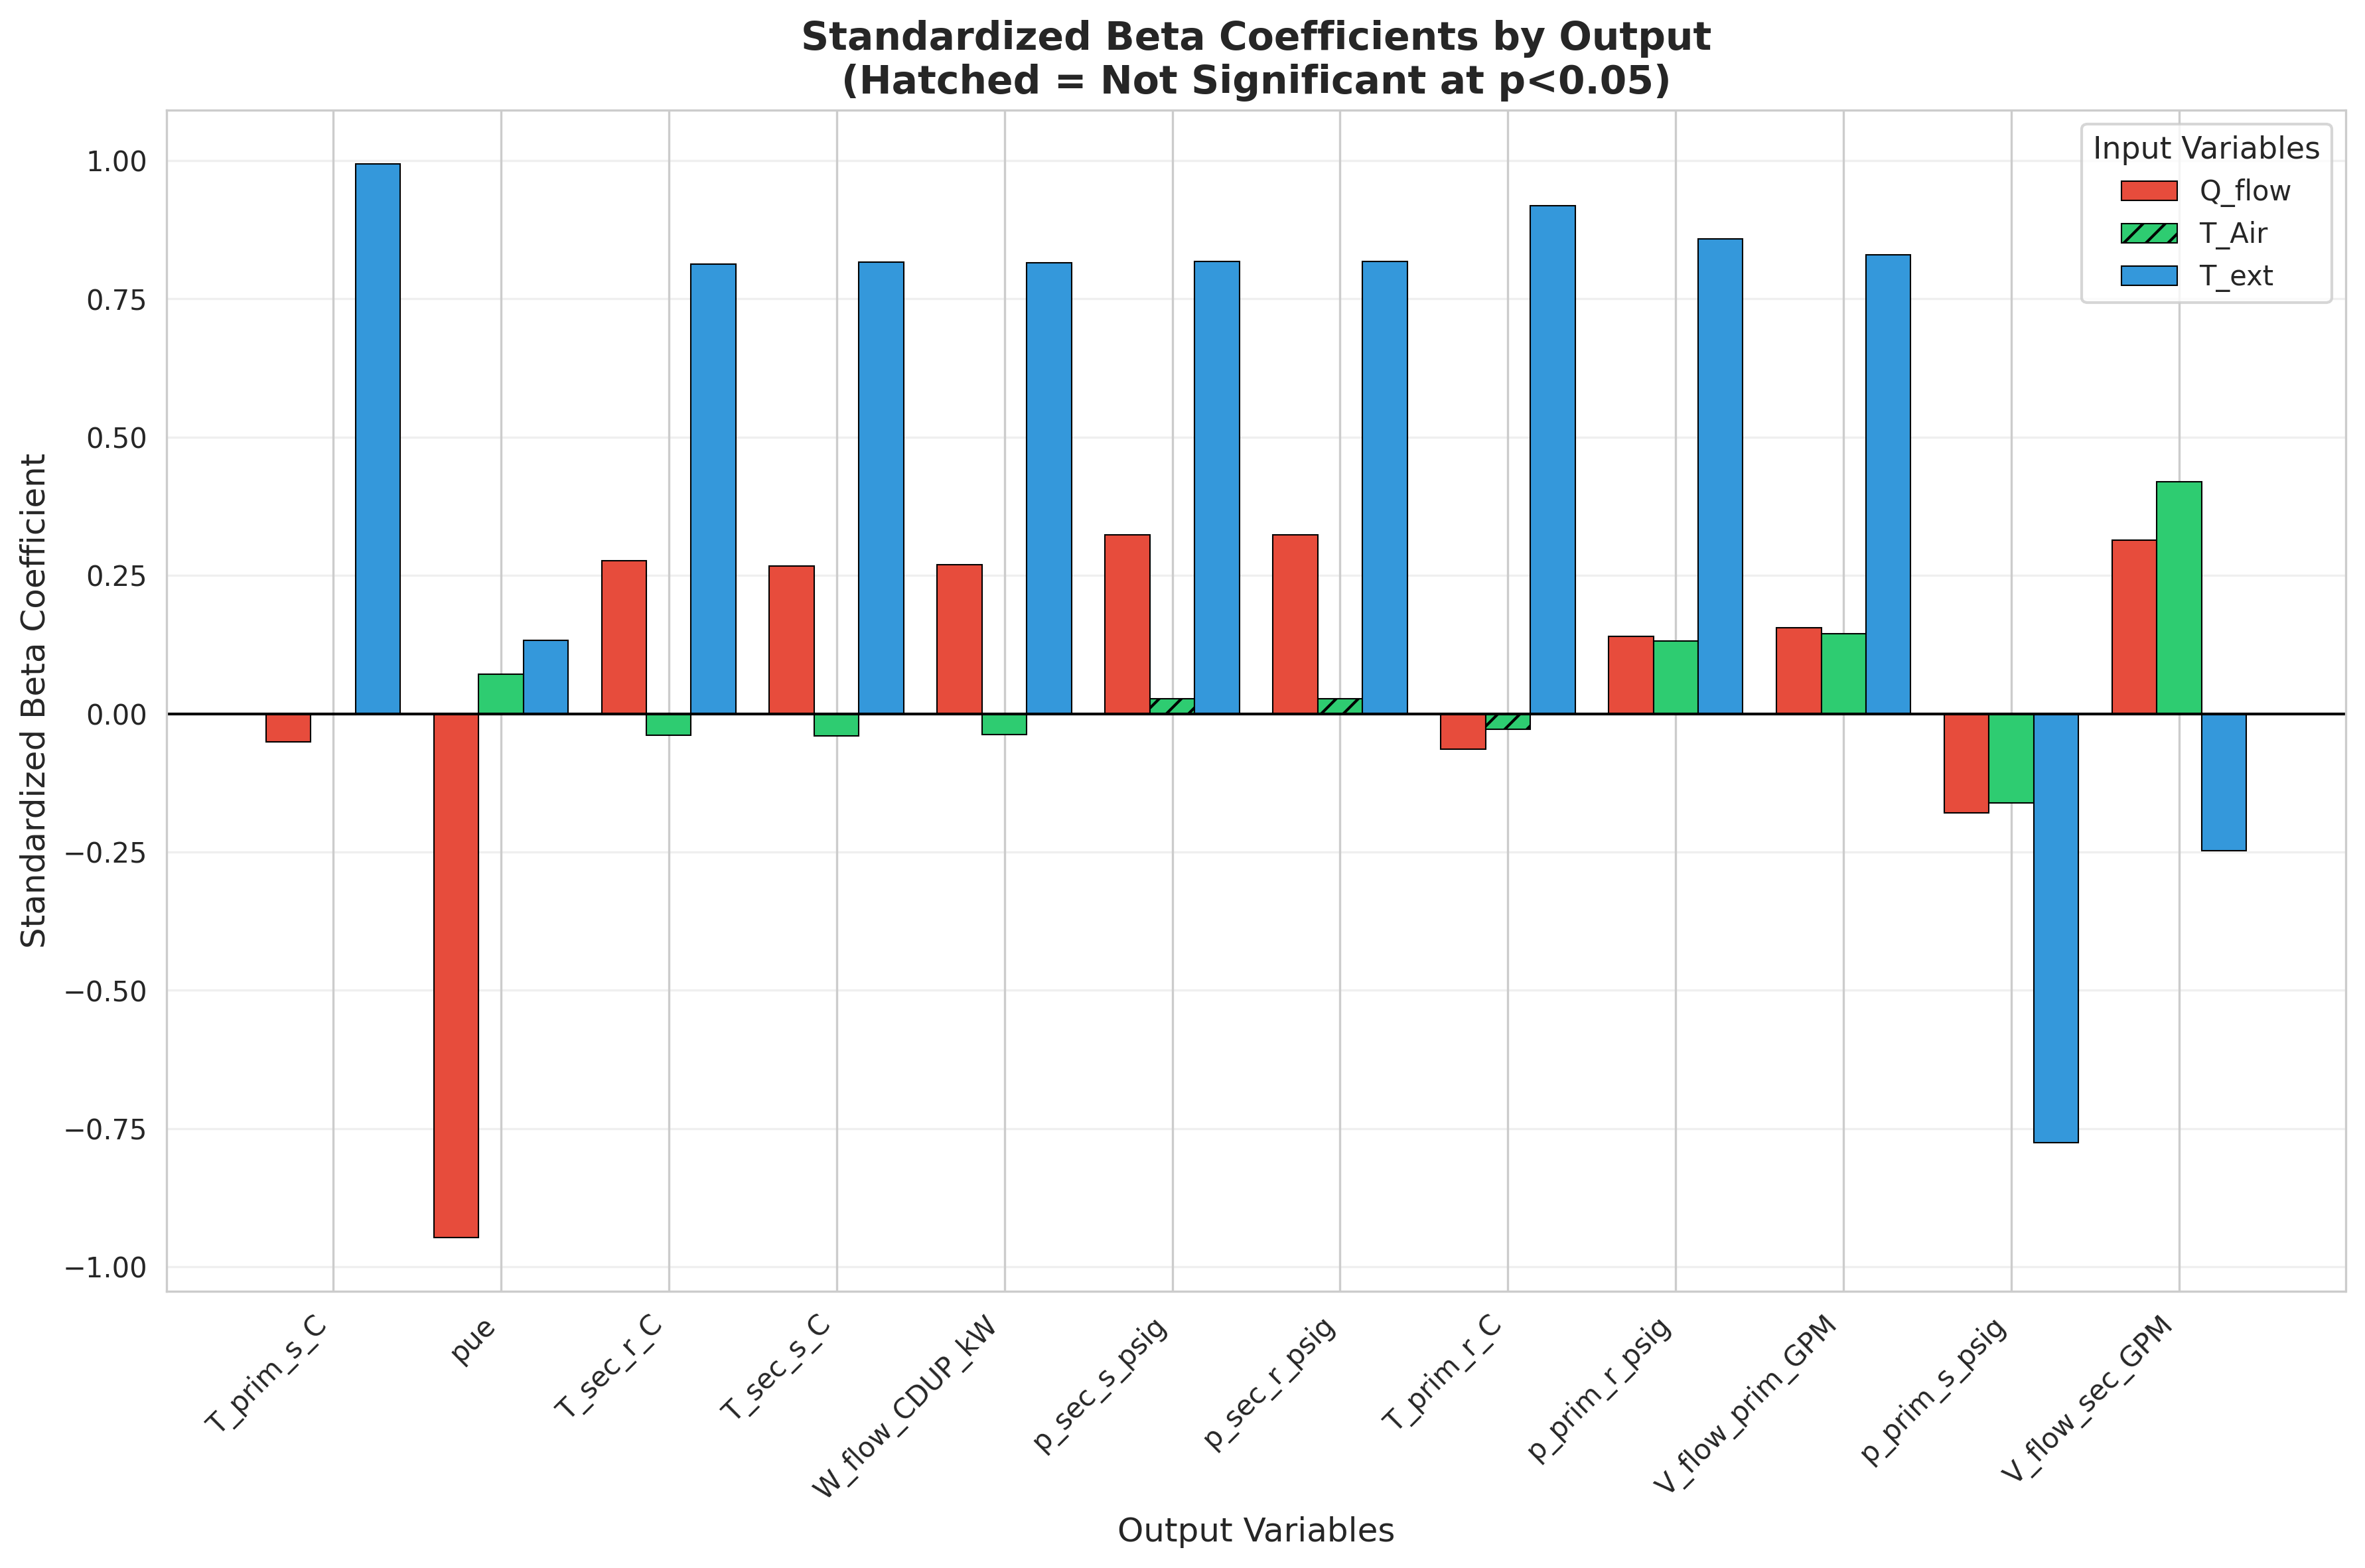

In [56]:
# Multiple Regression - Visualizations
beta_matrix = regression_analyzer.compute_beta_coefficient_matrix(regression_df)
pvalue_matrix = regression_analyzer.compute_significance_matrix(regression_df)
vif_summary = regression_analyzer.compute_vif_summary(regression_df)
variance_df = regression_analyzer.compute_variance_explained(regression_df)

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'regression')
os.makedirs(viz_dir, exist_ok=True)

create_beta_coefficient_plot(regression_df, viz_dir)
create_significance_heatmap(pvalue_matrix, viz_dir)
create_variance_explained_chart(variance_df, viz_dir)
create_vif_plot(vif_summary, viz_dir, threshold=10.0)
create_regression_summary_plot(regression_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'beta_coefficients.png'))


## 3. Lagged Effect Analysis

In [8]:

#  Lagged Effect Analysis - Setup
lagged_analyzer = LaggedEffectAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=MAX_LAG*40,
    min_lag=0,
    lag_step=5,
    cv_folds=5,
    significance_threshold=0.05
)

lag_prepared_data = lagged_analyzer.prepare_data(data)
print(f"Data prepared for lagged analysis. Max lag: {MAX_LAG*40}")


2026-02-05 14:53:55 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - LaggedEffectAnalyzer initialized for system: lassen
2026-02-05 14:53:55 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Max lag: 1200, Lag step: 5
2026-02-05 14:53:55 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Preparing data for lagged effect analysis...
2026-02-05 14:53:55 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for lagged analysis. Max lag: 1200


In [ ]:

# Lagged Effect Analysis - Compute
print("Analyzing lagged effects (this may take a while)...")
lag_df = lagged_analyzer.analyze_lagged_effects(lag_prepared_data)

print(f"\nRelationships analyzed: {len(lag_df)}")
print(f"Need sequence inputs: {lag_df['needs_sequence_input'].sum()}")
print(f"Average memory length: {lag_df['memory_length'].mean():.1f} lags")

# Display relationships needing sequences
needs_seq = lag_df[lag_df['needs_sequence_input']]
print(f"\nTop relationships requiring sequence inputs:")
print(needs_seq.nlargest(5, 'optimal_lag')[['input', 'output', 'optimal_lag', 'memory_length']])


In [10]:
# Lagged Effect Analysis - Summaries
cumulative_df = lagged_analyzer.compute_cumulative_effects(lag_df)
memory_summary = lagged_analyzer.get_memory_length_summary(lag_df)

print("Memory Length Summary:")
print(memory_summary)

print("\nCumulative Effects (sample):")
print(cumulative_df.head(10))


2026-02-05 16:25:22 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing cumulative effects...
2026-02-05 16:25:22 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.lagged_effect_analyzer - INFO - Computing memory length summary...


Memory Length Summary:
    input  mean_memory_length  max_memory_length  mean_optimal_lag  \
0  Q_flow               300.0               1200        498.333333   
1   T_Air               115.0               1200        176.250000   
2   T_ext               900.0               1200        603.333333   

   pct_needs_sequence  mean_r2_improvement  
0            0.000000             0.156460  
1           33.333333             0.237203  
2           66.666667             0.508783  

Cumulative Effects (sample):
    input           output  lag  coefficient  cumulative_effect
0  Q_flow  V_flow_prim_GPM    0    47.859469          47.859469
1  Q_flow  V_flow_prim_GPM    5   -48.927054          -1.067585
2  Q_flow  V_flow_prim_GPM   10     3.770717           2.703132
3  Q_flow  V_flow_prim_GPM   15    -0.852815           1.850318
4  Q_flow  V_flow_prim_GPM   20     0.455167           2.305485
5  Q_flow  V_flow_prim_GPM   25     0.165045           2.470530
6  Q_flow  V_flow_prim_GPM   30    -0.

2026-02-05 16:25:22 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating lag coefficient plots in parallel...
2026-02-05 16:25:31 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created 36/36 lag coefficient plots
2026-02-05 16:25:31 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating lag heatmap...
2026-02-05 16:25:34 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created lag heatmap
2026-02-05 16:25:34 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating memory length plot...
2026-02-05 16:25:35 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Created memory length plot
2026-02-05 16:25:35 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.lagged_effect_visualizer - INFO - Creating cumulative effec

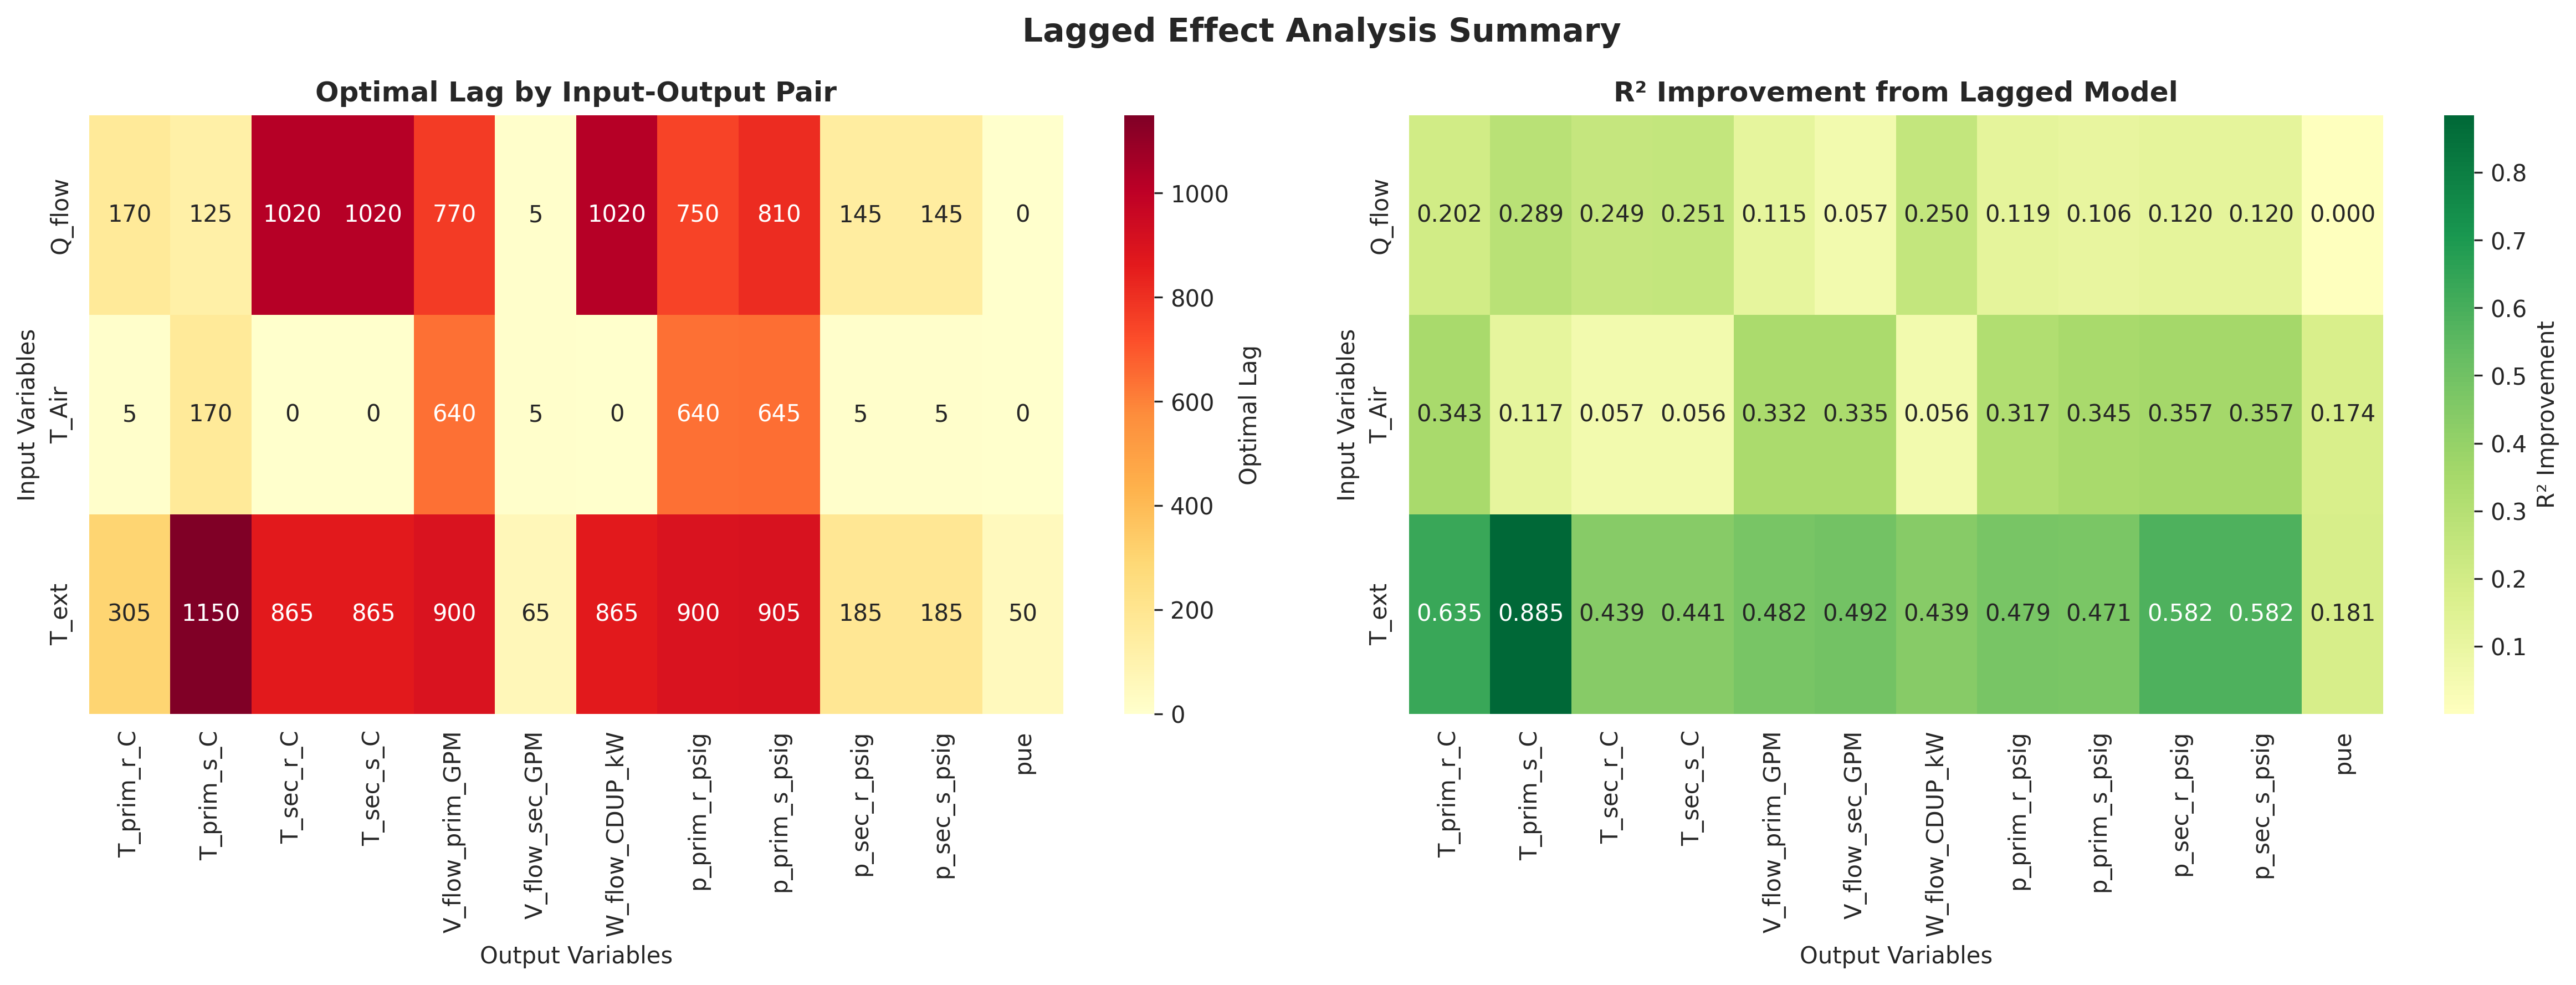

In [11]:

#  Lagged Effect - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'lagged_effects')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(lagged_analyzer, '_full_lag_results'):
    create_lag_coefficient_plots(
        lagged_analyzer._full_lag_results,
        viz_dir,
        n_workers=N_WORKERS
    )

create_lag_heatmap(lag_df, viz_dir)
create_memory_length_plot(memory_summary, viz_dir)
create_cumulative_effect_summary(cumulative_df, viz_dir)
create_lag_analysis_summary(lag_df, viz_dir)

Image(filename=os.path.join(viz_dir, 'lag_heatmap.png'))


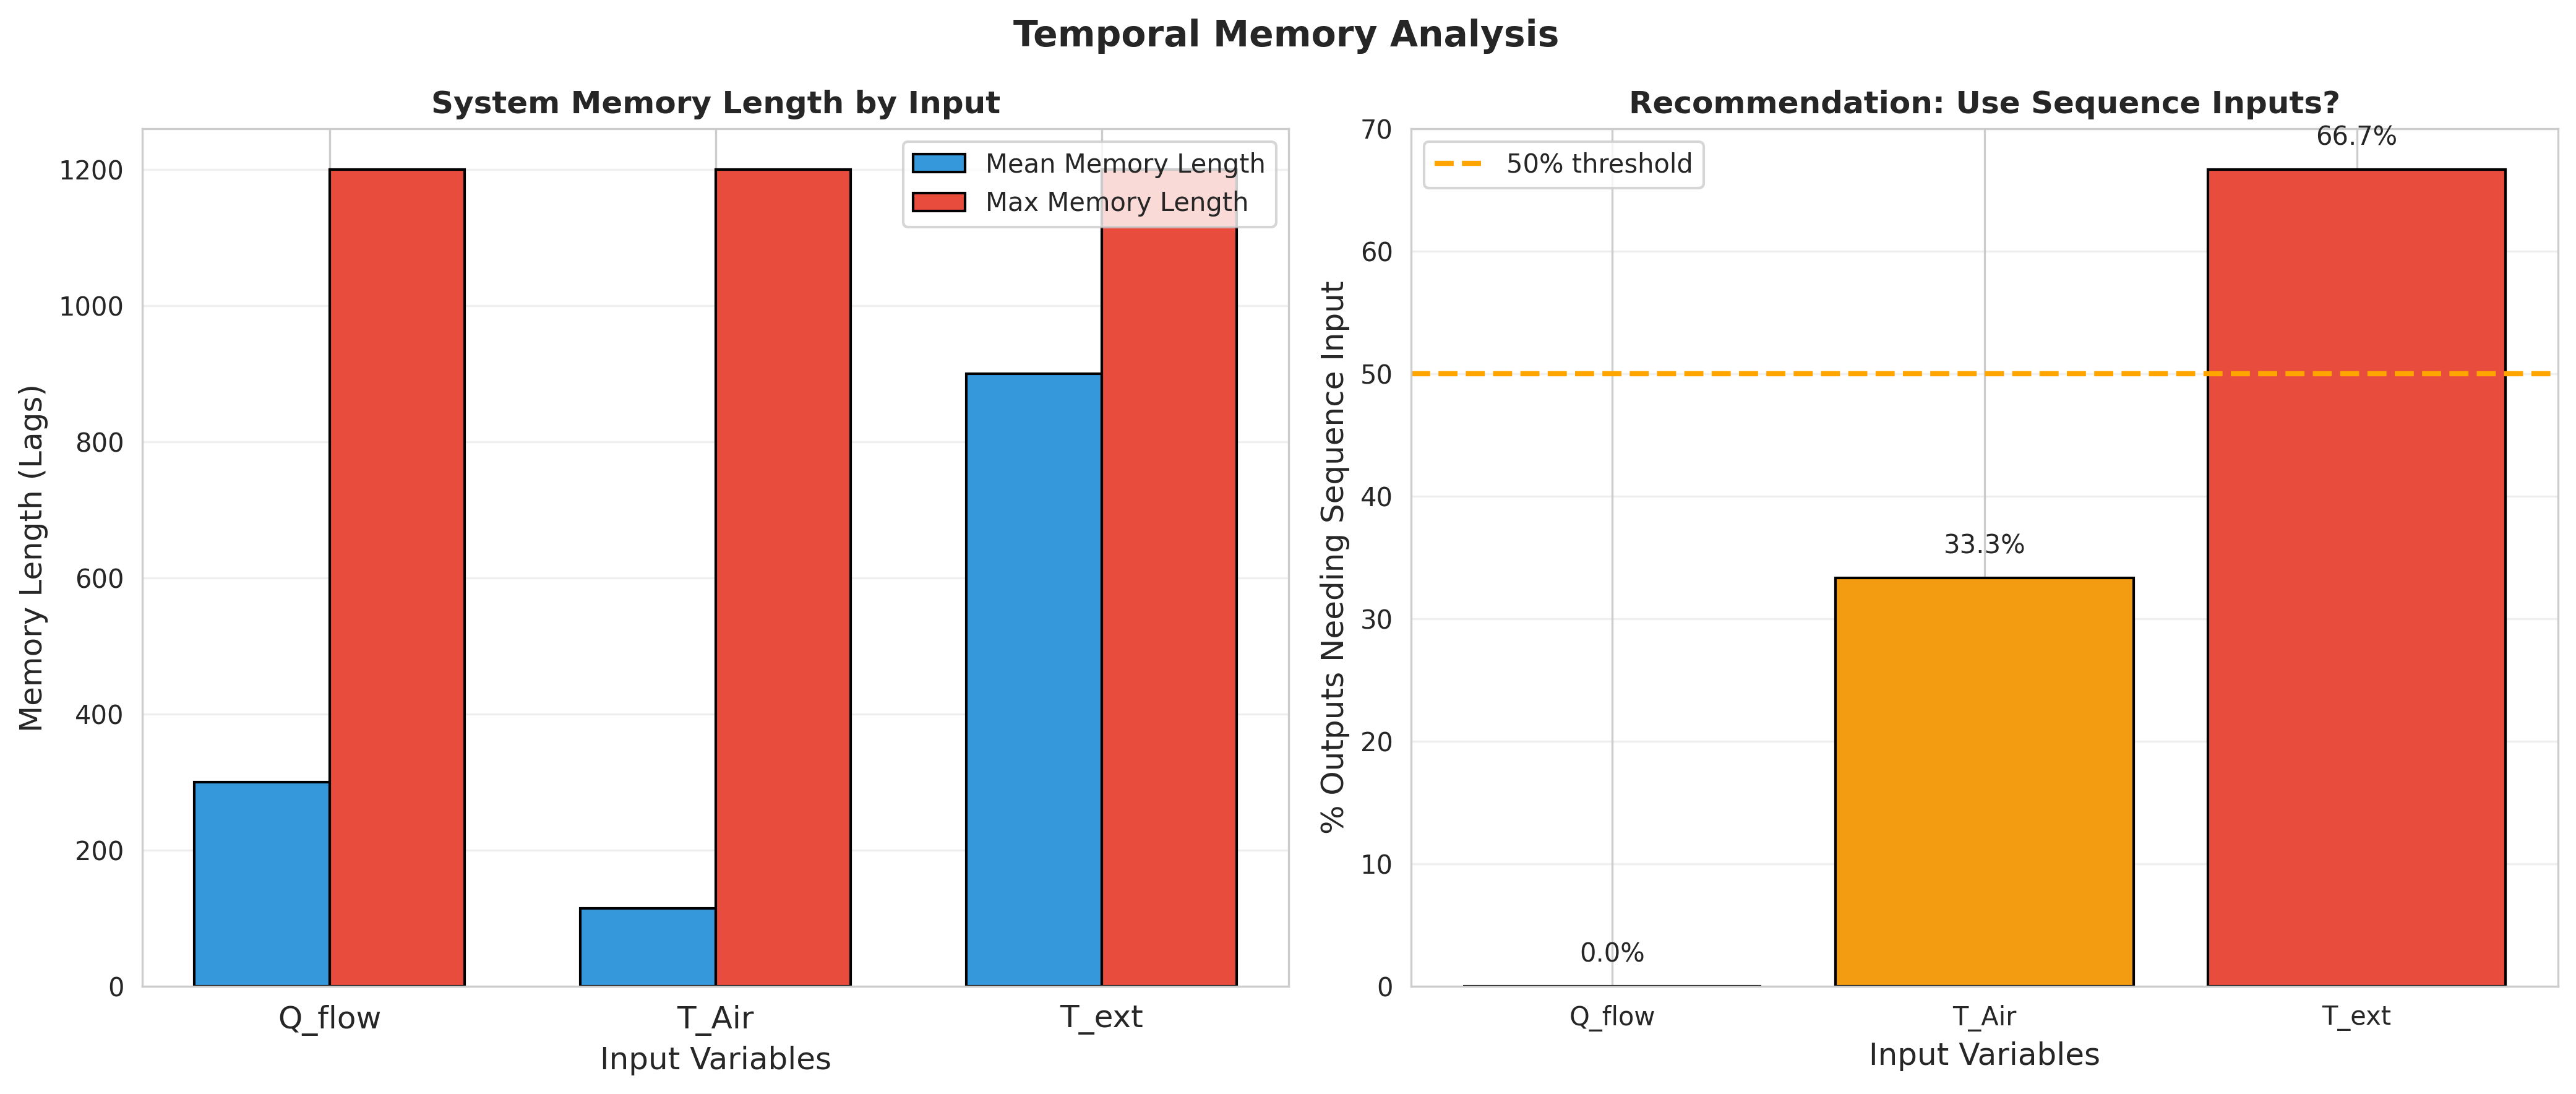

In [12]:
Image(filename=os.path.join(viz_dir, 'memory_length.png'))


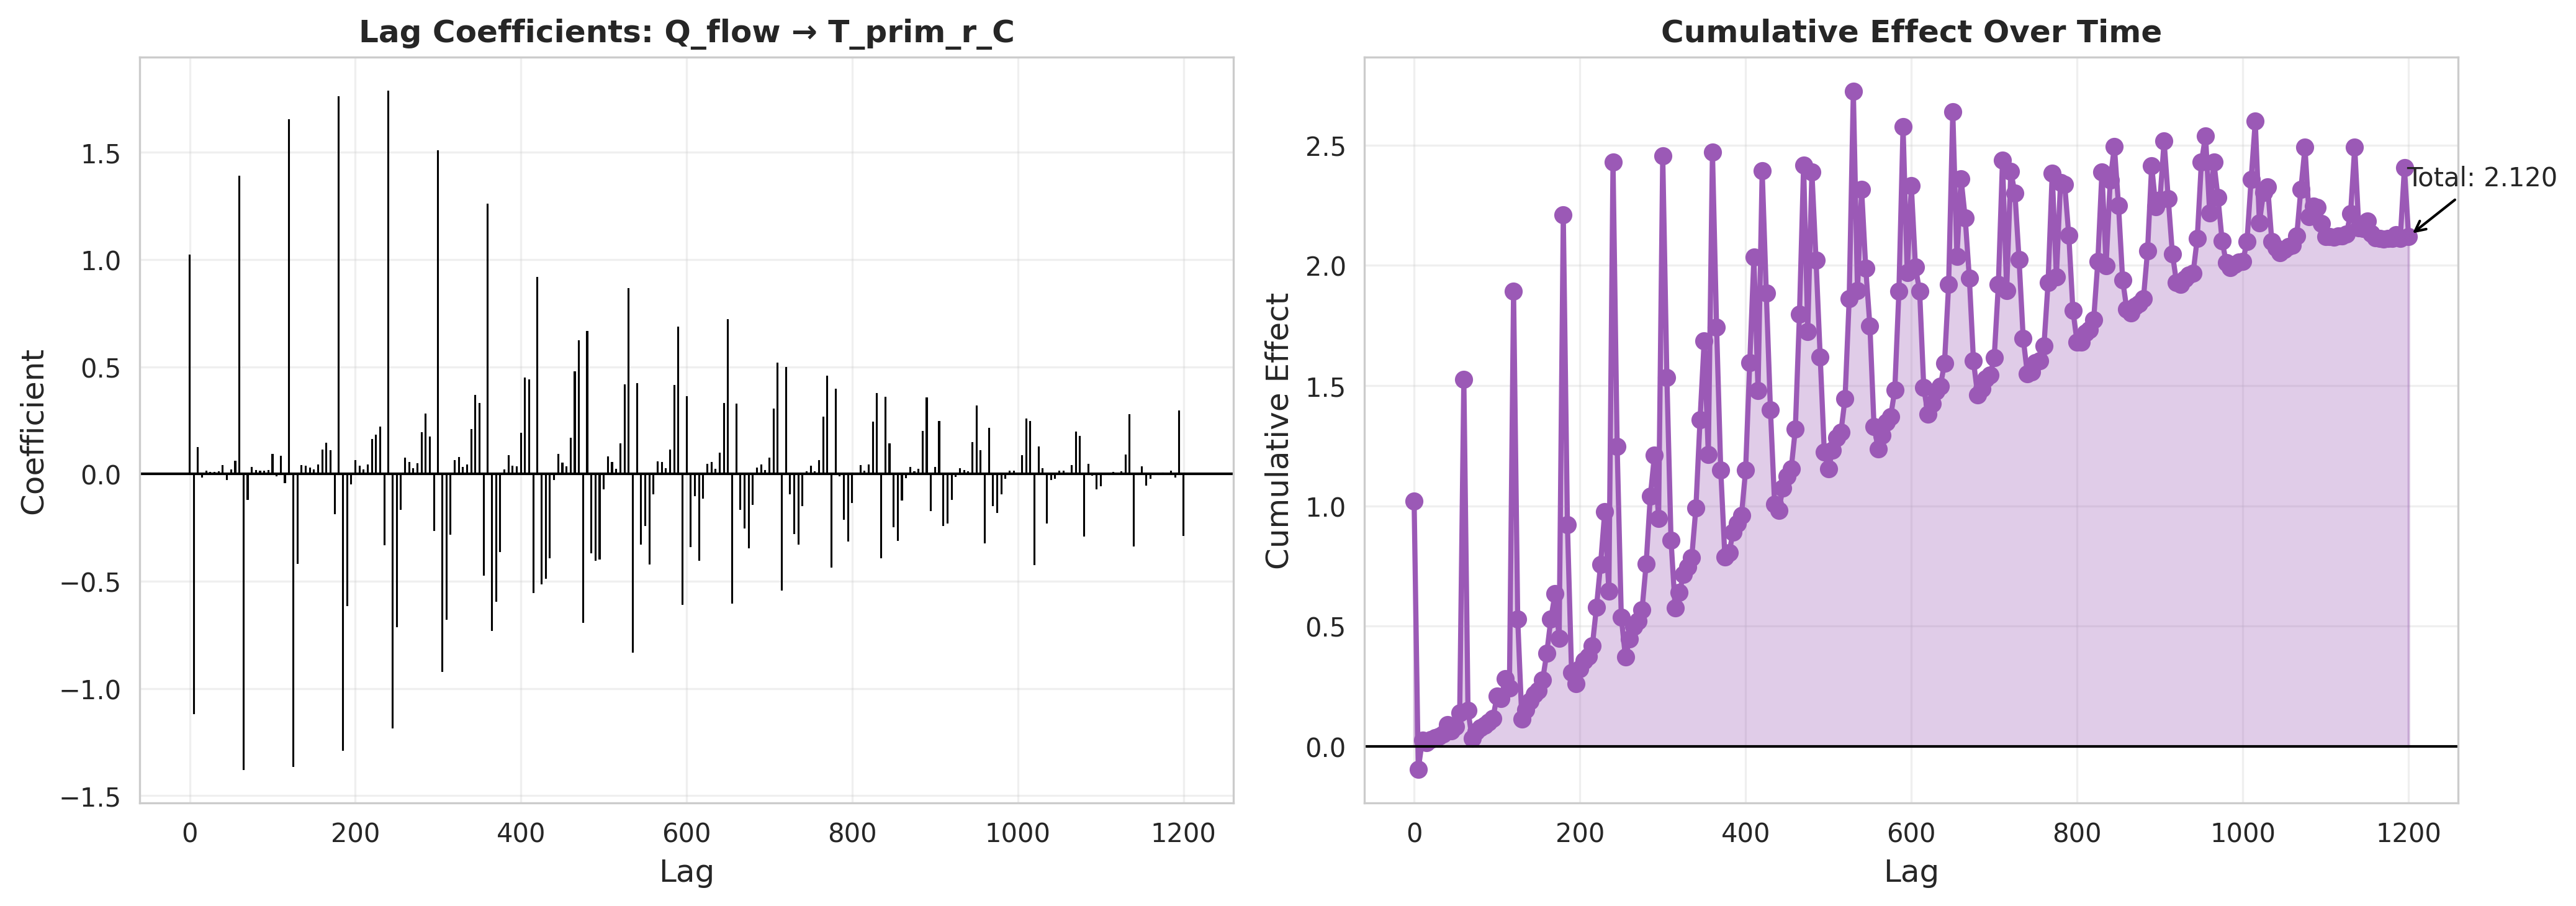

In [13]:
Image(filename=os.path.join(viz_dir, 'lag_coefficients_Q_flow_T_prim_r_C.png'))


## 4. Autocorrelation Analysis

In [9]:
#  Autocorrelation Analysis - Setup
autocorr_analyzer = AutocorrelationAnalyzer(
    system_name=SYSTEM_NAME,
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    max_lag=1500,
    confidence_level=0.95,
    compute_pacf=True,
    compute_ccf=True
)

autocorr_prepared_data = autocorr_analyzer.prepare_data(data)
print("Data prepared for autocorrelation analysis")


2026-02-05 19:45:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - AutocorrelationAnalyzer initialized for system: lassen
2026-02-05 19:45:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Max lag: 1500, Confidence level: 0.95
2026-02-05 19:45:50 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Preparing data for autocorrelation analysis...
2026-02-05 19:45:51 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Prepared data: 3 inputs, 11 outputs


Data prepared for autocorrelation analysis


In [10]:
#   Autocorrelation Analysis - ACF/PACF
print("Computing ACF and PACF...")
input_acf_df, output_acf_df = autocorr_analyzer.analyze_autocorrelation(autocorr_prepared_data)

print(f"\nInput ACF results: {len(input_acf_df)} variables")
print(f"Output ACF results: {len(output_acf_df)} variables")


2026-02-05 19:45:51 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Analyzing autocorrelation patterns...
2026-02-05 19:45:51 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Initializing Dask cluster for autocorrelation analysis...


Computing ACF and PACF...


2026-02-05 19:45:51 - distributed.scheduler - INFO - State start
2026-02-05 19:45:51 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-t19icl2f', purging
2026-02-05 19:45:51 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:43801
2026-02-05 19:45:51 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:42921/status
2026-02-05 19:45:51 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-02-05 19:45:51 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38685'
2026-02-05 19:45:51 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38839'
2026-02-05 19:45:51 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:43721'
2026-02-05 19:45:51 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44919'
2026-02-05 19:45:51 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:42691'
2026-02-05 19:45:51 - dis


Input ACF results: 3 variables
Output ACF results: 12 variables


In [11]:
input_acf_df

,variable,first_insignificant_lag,persistence,ar_order_suggestion,n_significant_acf_lags,n_significant_pacf_lags
0,Q_flow,87,126.526565,1453,1086,67
1,T_Air,154,163.489887,910,1158,39
2,T_ext,75,126.730188,1457,1215,39


In [12]:
output_acf_df

,variable,first_insignificant_lag,persistence,ar_order_suggestion,n_significant_acf_lags,n_significant_pacf_lags
0,V_flow_prim_GPM,NaN,948.194608,1,1500,1
1,V_flow_sec_GPM,938.0,362.468176,1455,1309,75
2,W_flow_CDUP_kW,NaN,817.983246,1,1500,1
3,T_prim_s_C,1313.0,500.124787,19,1468,19
4,T_prim_r_C,561.0,335.395621,20,1461,20
5,T_sec_s_C,NaN,817.713146,1,1500,1
6,T_sec_r_C,NaN,819.905743,1,1500,1
7,p_prim_s_psig,NaN,940.206230,1,1500,1
8,p_prim_r_psig,NaN,965.089552,1,1500,1
9,p_sec_s_psig,504.0,325.946117,20,1449,20


In [13]:

# Autocorrelation Analysis - Cross-Correlation
print("Computing cross-correlations...")
ccf_df = autocorr_analyzer.analyze_cross_correlation(autocorr_prepared_data)

print(f"\nCross-correlations computed: {len(ccf_df)}")

# Show strongest cross-correlations
ccf_df['abs_max_ccf'] = ccf_df['peak_ccf'].abs()
top_ccf = ccf_df.nlargest(10, 'abs_max_ccf')
print("\nTop 10 Cross-Correlations:")
print(top_ccf[['input', 'output', 'peak_ccf', 'peak_lag', 'n_significant_lags']])


2026-02-05 19:47:48 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Analyzing cross-correlation patterns...
2026-02-05 19:47:48 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Executing 36 CCF analyses...


Computing cross-correlations...


2026-02-05 19:48:09 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Completed CCF analysis for 36 input-output pairs



Cross-correlations computed: 36

Top 10 Cross-Correlations:
     input          output  peak_ccf  peak_lag  n_significant_lags
11  Q_flow             pue -0.998240         0                2275
27   T_ext      T_prim_s_C  0.527650       -62                2347
28   T_ext      T_prim_r_C  0.445007      -107                2293
33   T_ext    p_sec_s_psig  0.441499       -97                2708
34   T_ext    p_sec_r_psig  0.441474       -97                2708
15   T_Air      T_prim_s_C -0.357512       744                2483
13   T_Air  V_flow_sec_GPM  0.345488      -439                2474
1   Q_flow  V_flow_sec_GPM  0.342281        13                2342
25   T_ext  V_flow_sec_GPM  0.340990      -103                2700
22   T_Air    p_sec_r_psig  0.326027      -436                2504


In [14]:

# Temporal Recommendations
recommendations_df = autocorr_analyzer.compute_temporal_recommendations(output_acf_df, ccf_df)

print(f"Temporal recommendations for {len(recommendations_df)} outputs")
print(f"Need temporal modeling: {recommendations_df['needs_temporal_model'].sum()}")

# Display recommendations
temporal_needed = recommendations_df[recommendations_df['needs_temporal_model']]
print("\nOutputs Requiring Temporal Models:")
for _, row in temporal_needed.iterrows():
    print(f"\n{row['output']}:")
    print(f"  {row['recommendation']}")


2026-02-05 19:48:09 - fmu2ml.analysis.multivariate_effect_analysis.analyzers.autocorrelation_analyzer - INFO - Computing temporal modeling recommendations...


Temporal recommendations for 12 outputs
Need temporal modeling: 12

Outputs Requiring Temporal Models:

V_flow_prim_GPM:
  Use LSTM or sequence model with 1 lags. High persistence (948.2) indicates strong temporal dependencies.

V_flow_sec_GPM:
  Use LSTM or sequence model with 1455 lags. High persistence (362.5) indicates strong temporal dependencies.

W_flow_CDUP_kW:
  Use LSTM or sequence model with 1 lags. High persistence (818.0) indicates strong temporal dependencies.

T_prim_s_C:
  Use LSTM or sequence model with 19 lags. High persistence (500.1) indicates strong temporal dependencies.

T_prim_r_C:
  Use LSTM or sequence model with 20 lags. High persistence (335.4) indicates strong temporal dependencies.

T_sec_s_C:
  Use LSTM or sequence model with 1 lags. High persistence (817.7) indicates strong temporal dependencies.

T_sec_r_C:
  Use LSTM or sequence model with 1 lags. High persistence (819.9) indicates strong temporal dependencies.

p_prim_s_psig:
  Use LSTM or sequence mo

2026-02-05 19:48:09 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating ACF/PACF plots in parallel...
2026-02-05 19:48:23 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created 15/15 ACF/PACF plots
2026-02-05 19:48:23 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating CCF plots in parallel...
2026-02-05 19:48:43 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created 36/36 CCF plots
2026-02-05 19:48:43 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating persistence summary...
2026-02-05 19:48:46 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Created persistence summary
2026-02-05 19:48:46 - fmu2ml.analysis.multivariate_effect_analysis.visualizers.autocorrelation_visualizer - INFO - Creating 

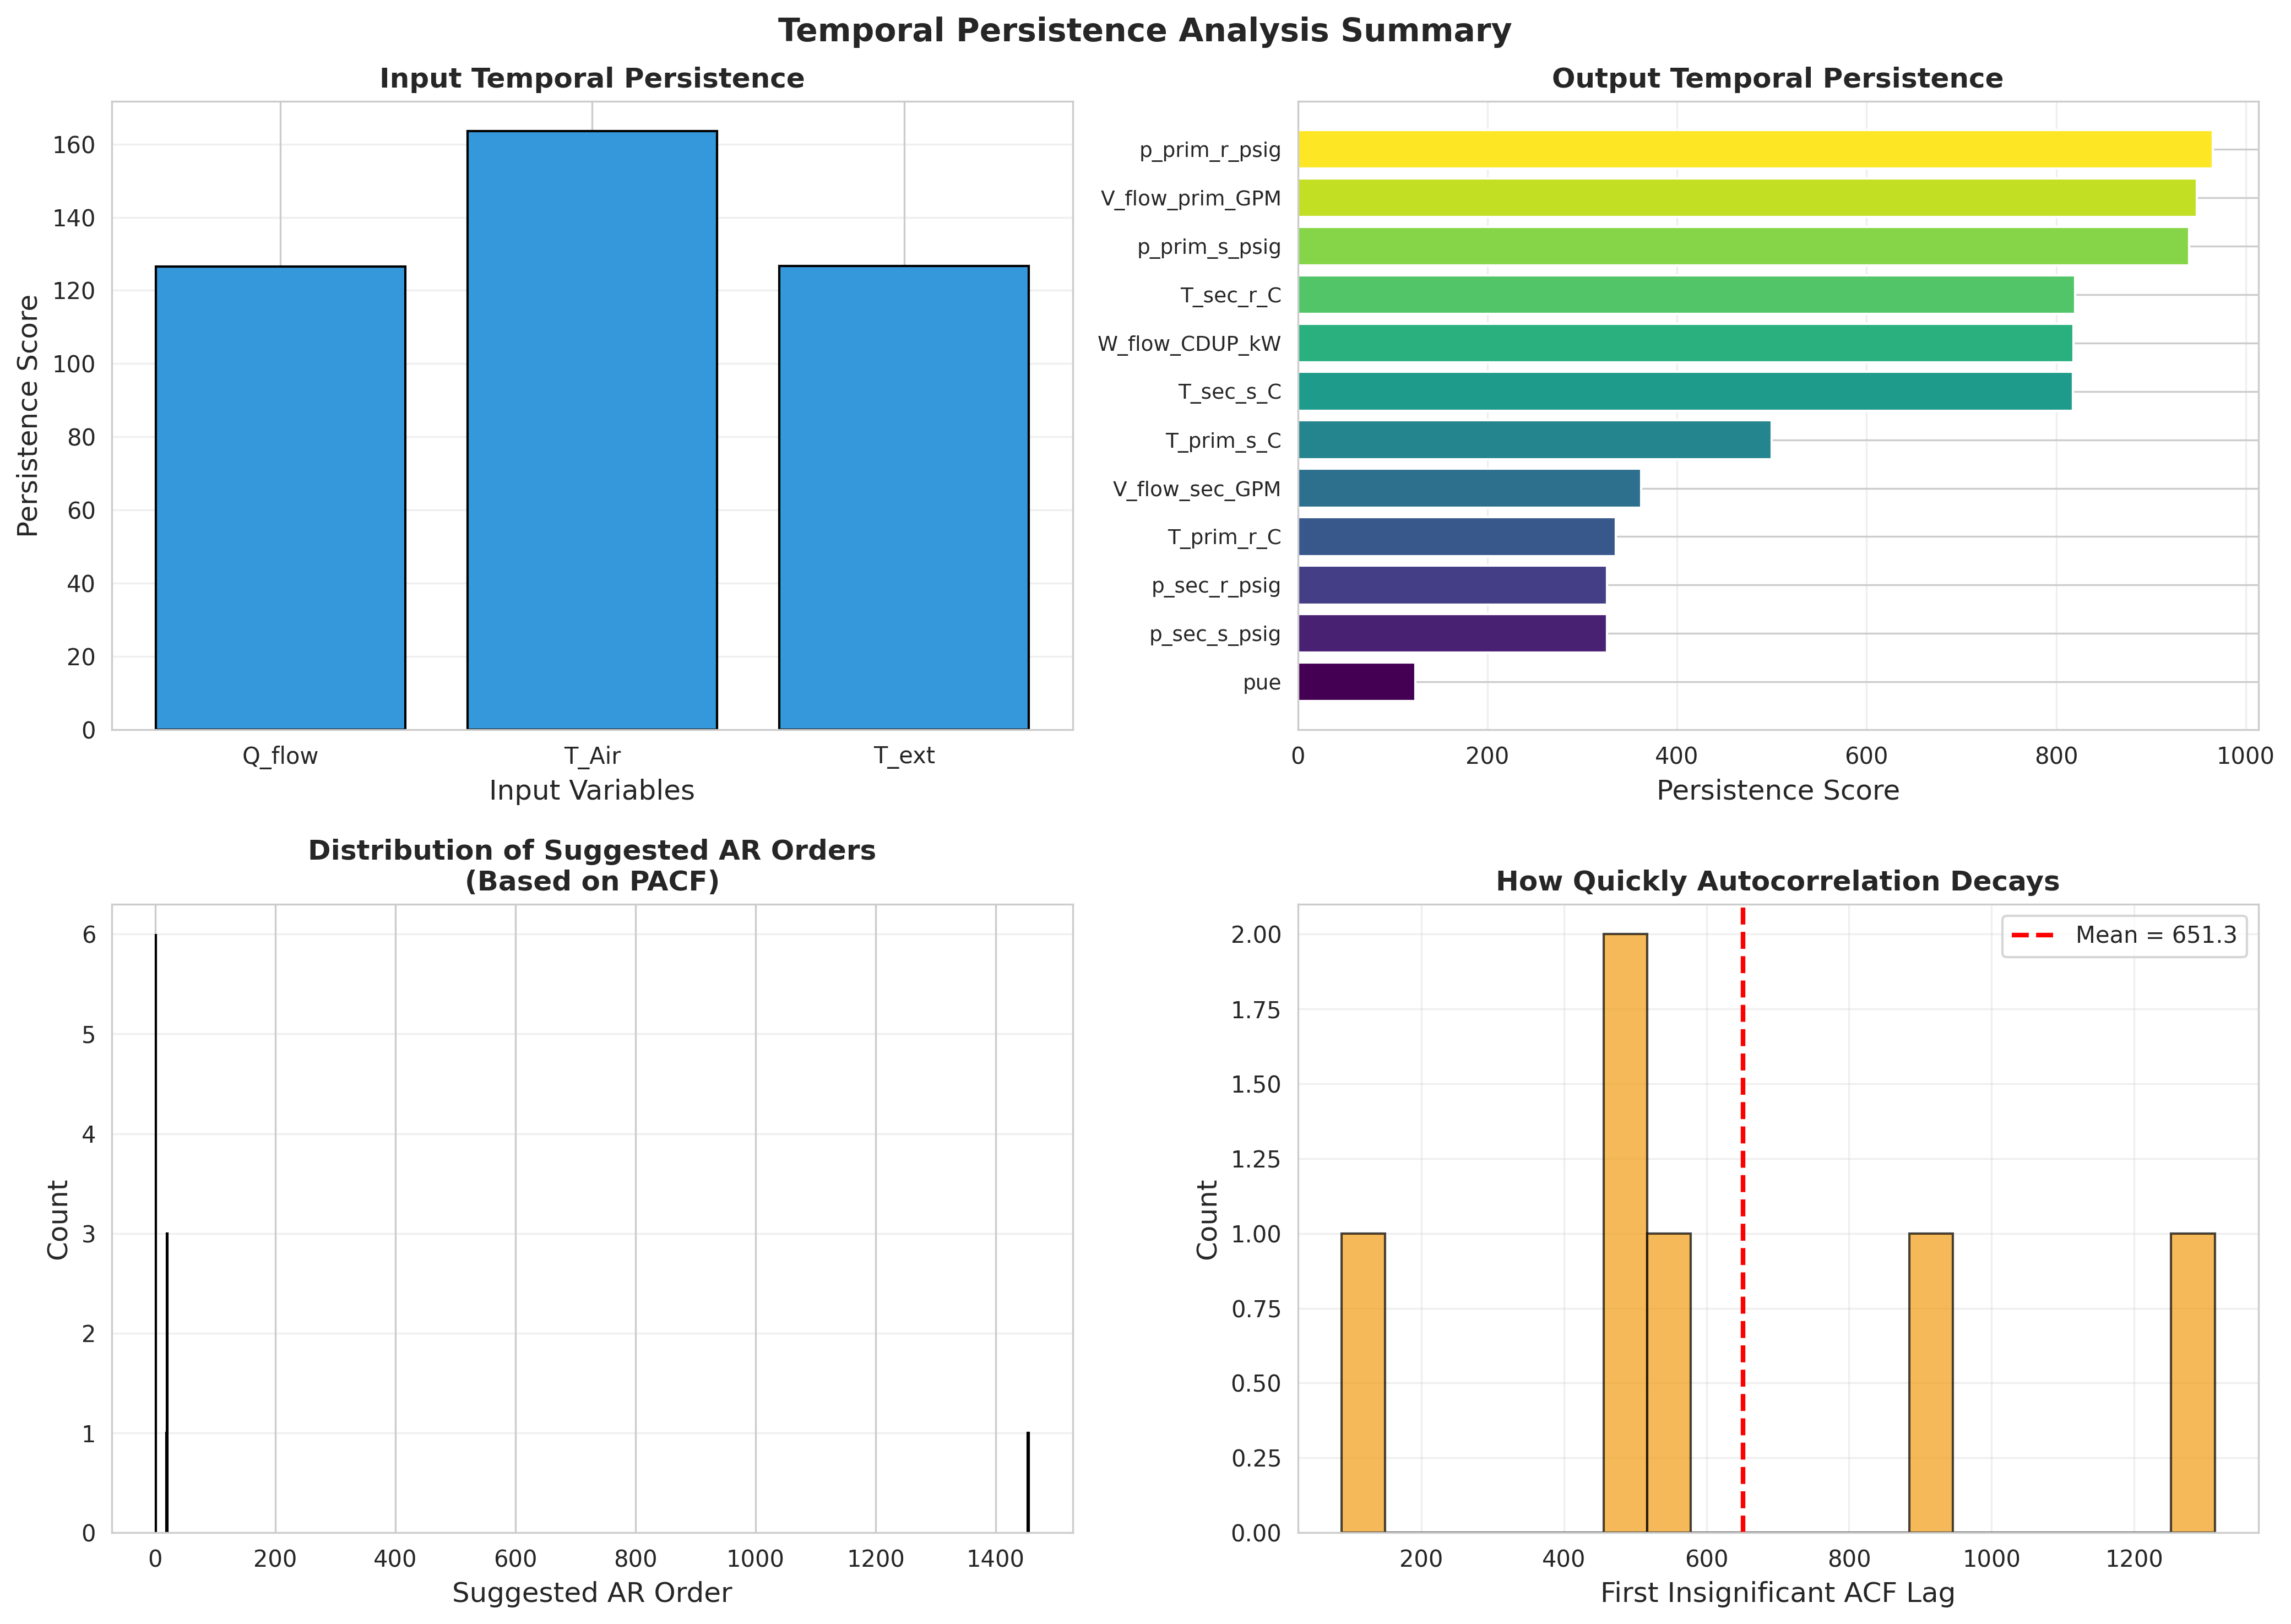

In [15]:

# Autocorrelation - Visualizations
viz_dir = os.path.join(OUTPUT_DIR, 'visualizations', 'autocorrelation')
os.makedirs(viz_dir, exist_ok=True)

if hasattr(autocorr_analyzer, '_acf_results'):
    create_acf_plots(autocorr_analyzer._acf_results, viz_dir, n_workers=N_WORKERS)

if hasattr(autocorr_analyzer, '_ccf_results'):
    create_ccf_plots(autocorr_analyzer._ccf_results, viz_dir, n_workers=N_WORKERS)

create_persistence_summary(input_acf_df, output_acf_df, viz_dir)
create_ccf_heatmap(ccf_df, viz_dir)
create_temporal_recommendations_plot(recommendations_df, viz_dir, )

Image(filename=os.path.join(viz_dir, 'persistence_summary.png'))


In [ ]:
#  Export Results Summary
# Save all results
partial_df.to_csv(os.path.join(OUTPUT_DIR, 'partial_correlations.csv'), index=False)
regression_df.to_csv(os.path.join(OUTPUT_DIR, 'multiple_regression.csv'), index=False)
lag_df.to_csv(os.path.join(OUTPUT_DIR, 'lagged_effects.csv'), index=False)
input_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'input_acf.csv'), index=False)
output_acf_df.to_csv(os.path.join(OUTPUT_DIR, 'output_acf.csv'), index=False)
ccf_df.to_csv(os.path.join(OUTPUT_DIR, 'cross_correlations.csv'), index=False)
recommendations_df.to_csv(os.path.join(OUTPUT_DIR, 'temporal_recommendations.csv'), index=False)

print(f"All results saved to: {OUTPUT_DIR}")
print("\nFiles created:")
print("  - partial_correlations.csv")
print("  - multiple_regression.csv")
print("  - lagged_effects.csv")
print("  - input_acf.csv, output_acf.csv")
print("  - cross_correlations.csv")
print("  - temporal_recommendations.csv")
print("  - visualizations/ (multiple subfolders)")

#  Cleanup
# Close Dask clients
partial_analyzer._close_dask_client()
regression_analyzer._close_dask_client()
lagged_analyzer._close_dask_client()
autocorr_analyzer._close_dask_client()

print("Analysis complete! Dask clients closed.")